
=== Task: PullCube-v1 ===
  Found 40 experiments (expected up to ~35)
  Algo sac_ae: 5 runs (nominal 5)
  Algo smg: 5 runs (nominal 5)
  Algo madi: 5 runs (nominal 5)
  Algo sada: 5 runs (nominal 5)
  Algo samg: 5 runs (nominal 5)
  Algo drqv2: 5 runs (nominal 5)
  Algo segdac_sac_sam_enc_decoder_q_cond: 5 runs (nominal 5)

=== Task: PickCube-v1 ===
  Found 40 experiments (expected up to ~35)
  Algo sac_ae: 5 runs (nominal 5)
  Algo smg: 5 runs (nominal 5)
  Algo madi: 5 runs (nominal 5)
  Algo sada: 5 runs (nominal 5)
  Algo samg: 5 runs (nominal 5)
  Algo drqv2: 5 runs (nominal 5)
  Algo segdac_sac_sam_enc_decoder_q_cond: 5 runs (nominal 5)

=== Task: PullCubeTool-v1 ===
  Found 40 experiments (expected up to ~35)
  Algo sac_ae: 5 runs (nominal 5)
  Algo smg: 5 runs (nominal 5)
  Algo madi: 5 runs (nominal 5)
  Algo sada: 5 runs (nominal 5)
  Algo samg: 5 runs (nominal 5)
  Algo drqv2: 5 runs (nominal 5)
  Algo segdac_sac_sam_enc_decoder_q_cond: 5 runs (nominal 5)

=== Task: LiftPeg

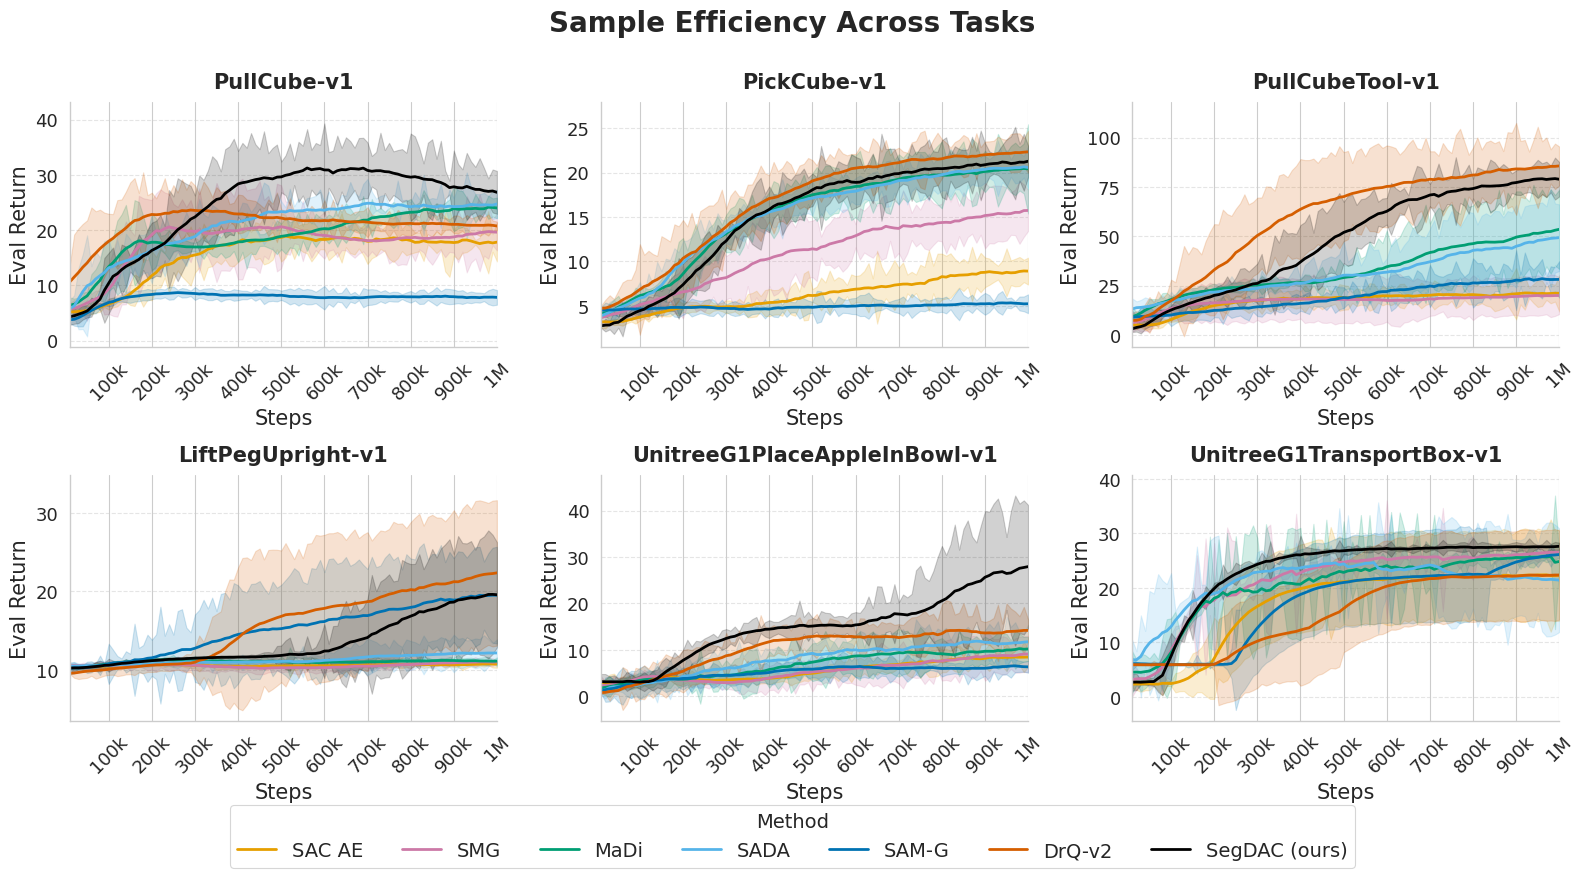

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.ticker import MultipleLocator, FuncFormatter

from comet_ml.query import Parameter, Tag
import comet_ml

PROJECT_NAME = "segdac"
WORKSPACE_NAME = "alexandrebrown"
SMOOTHING_ALPHA = 0.9

MIN_STEP = 10_000

comet_ml.login()
api = comet_ml.API()

EXPECTED_NB_SEEDS = 5

tasks = [
    # "PushCube-v1",
    "PullCube-v1",
    "PickCube-v1",
    # "PokeCube-v1",
    "PullCubeTool-v1",
    "LiftPegUpright-v1",
    "UnitreeG1PlaceAppleInBowl-v1",
    "UnitreeG1TransportBox-v1",
]

logged_task_names = {
    "PushCube-v1": ["PushCube-v1", "PushCubeFixed-v1"],
    "PullCube-v1": ["PullCube-v1"],
    "PickCube-v1": ["PickCube-v1", "PickCubeVisual-v1"],
    "PokeCube-v1": ["PokeCube-v1"],
    "PullCubeTool-v1": ["PullCubeTool-v1"],
    "LiftPegUpright-v1": ["LiftPegUpright-v1"],
    "UnitreeG1PlaceAppleInBowl-v1": ["UnitreeG1PlaceAppleInBowl-v1"],
    "UnitreeG1TransportBox-v1": ["UnitreeG1TransportBox-v1"],
}

color_map = {
    # "sac_state": "#009E73",
    "sac_ae": "#E69F00",
    "smg":  "#CC79A7",
    "madi": "#009E73",
    "sada": "#56B4E9",
    #"ftd": "#0077BB",
    "samg":  "#0072B2",
    "drqv2": "#D55E00",
    "segdac_sac_sam_enc_decoder_q_cond": "#000000",
    # "segdac_decoder_q_value_change_aux_critic": "#0008FF",
}

algo_name_mapping = {
    # "sac_state": "SAC State",
    "sac_ae": "SAC AE",
    "smg": "SMG",
    "madi": "MaDi",
    "sada": "SADA",
    # "ftd": "FTD",
    "samg":  "SAM-G",
    "drqv2": "DrQ-v2",
    "segdac_sac_sam_enc_decoder_q_cond": "SegDAC (ours)",
    # "segdac_decoder_q_value_change_aux_critic": "SegDAC + Aux (ours)",
}

output_eval_results_folder = Path("results/eval")
output_plots_folder = output_eval_results_folder / Path("plots")
output_plots_folder.mkdir(parents=True, exist_ok=True)

sns.set_theme(context="paper", style="whitegrid", font_scale=1.2)


def xfmt(x, pos):
    if x >= 1_000_000:
        return f"{int(x/1_000_000)}M"
    else:
        return f"{int(x/1000)}k"


def smooth_curve(curve, alpha):
    """
    Smooth a curve using an exponential moving average, matching CometML's formula.
    alpha: The smoothing factor (0=raw, 1=max smoothing).
    """
    if alpha == 0:
        return curve

    beta = alpha
    alpha = 1 - beta

    smoothed = np.zeros_like(curve)
    smoothed[0] = curve[0]
    for i in range(1, len(curve)):
        smoothed[i] = alpha * curve[i] + beta * smoothed[i - 1]
    return smoothed


nb_cols = 3
fig, axes = plt.subplots(2, nb_cols, figsize=(16, 9), sharex=True, sharey=False)
plt.subplots_adjust(
    wspace=0.18, hspace=0.18, left=0.07, right=0.98, top=0.90, bottom=0.18
)

for idx, task_name in enumerate(tasks):
    print(f"\n=== Task: {task_name} ===")
    output_data = {}
    task_experiments = []

    for logged_task in logged_task_names[task_name]:
        baselines_experiments = api.query(
            WORKSPACE_NAME,
            PROJECT_NAME,
            (Parameter("env|id") == logged_task) & Tag("baseline"),
        )
        segdac_experiments = api.query(
            WORKSPACE_NAME,
            PROJECT_NAME,
            (Parameter("env|id") == logged_task) & Tag("paper-result"),
        )
        task_experiments += (baselines_experiments + segdac_experiments)

    nb_algos = len(algo_name_mapping.keys())
    expected_number_of_runs = EXPECTED_NB_SEEDS * nb_algos
    print(
        f"  Found {len(task_experiments)} experiments "
        f"(expected up to ~{expected_number_of_runs})"
    )

    algo_to_task_metrics = {}

    for algo_name in algo_name_mapping.keys():
        algo_experiments = []
        for experiment in task_experiments:
            summary = experiment.get_parameters_summary("algo|name")
            algo_param = summary.get("valueCurrent", None)
            if algo_param is None:
                continue
            if algo_name.lower() in algo_param.lower():
                algo_experiments.append(experiment)

        if len(algo_experiments) == 0:
            print(f"  [INFO] No experiments for algo {algo_name} on {task_name}")
            continue

        print(
            f"  Algo {algo_name}: {len(algo_experiments)} runs "
            f"(nominal {EXPECTED_NB_SEEDS})"
        )

        seed_step_to_ret = []
        for algo_experiment in algo_experiments:
            unique_experiment_returns = {}
            experiment_returns = sorted(
                algo_experiment.get_metrics("eval_return"),
                key=lambda x: x["step"],
            )
            for exp_return in experiment_returns:
                step = int(exp_return["step"])
                if step not in unique_experiment_returns:
                    unique_experiment_returns[step] = float(
                        exp_return["metricValue"]
                    )

            # Filter out early steps (e.g. 0) so that all curves start at >= 10k
            filtered_returns = {
                s: v for s, v in unique_experiment_returns.items() if s >= MIN_STEP
            }

            if len(filtered_returns) > 0:
                seed_steps = sorted(filtered_returns.keys())
                seed_returns_raw = np.array([filtered_returns[s] for s in seed_steps], dtype=float)
                seed_step_to_ret.append(dict(zip(seed_steps, seed_returns_raw)))

        if len(seed_step_to_ret) == 0:
            print(f"  [WARN] All runs for {algo_name} empty after MIN_STEP filter, skipping.")
            continue

        all_steps = sorted({s for d in seed_step_to_ret for s in d.keys()})
        all_steps_arr = np.array(all_steps, dtype=int)

        means = []
        stds = []
        for s in all_steps:
            vals = [d[s] for d in seed_step_to_ret if s in d]
            vals = np.asarray(vals, dtype=float)
            means.append(vals.mean())
            stds.append(vals.std())
        means = np.asarray(means)
        stds = np.asarray(stds)

        output_data[algo_name] = {}
        for seed_idx, d in enumerate(seed_step_to_ret):
            seed_steps = sorted(d.keys())
            seed_returns = [d[st] for st in seed_steps]
            output_data[algo_name][f"seed_{seed_idx+1}"] = {
                "return": seed_returns,
                "step": seed_steps,
            }

        output_data[algo_name]["aggregated"] = {
            "return_mean": means.tolist(),
            "return_std": stds.tolist(),
            "step": all_steps,
        }

        algo_to_task_metrics[algo_name] = {
            "return_mean": means,
            "return_std": stds,
            "step": all_steps_arr,
        }

    ax = axes[idx // nb_cols, idx % nb_cols]

    if len(algo_to_task_metrics) == 0:
        ax.set_title(task_name + " (no data)")
        ax.axis("off")
        continue

    last_step = max(m["step"][-1] for m in algo_to_task_metrics.values())
    nb_ticks = 10
    tick_step = max(last_step // nb_ticks, 1)
    ax.xaxis.set_major_locator(MultipleLocator(tick_step))
    ax.xaxis.set_major_formatter(FuncFormatter(xfmt))

    local_ymax = 0.0

    for algo_name in algo_name_mapping.keys():
        if algo_name not in algo_to_task_metrics:
            continue

        color = color_map[algo_name]
        data = algo_to_task_metrics[algo_name]

        steps = np.asarray(data["step"])
        return_means = np.asarray(data["return_mean"])
        return_stds = np.asarray(data["return_std"])

        return_means_smooth = smooth_curve(return_means, SMOOTHING_ALPHA)

        lower = return_means_smooth - return_stds
        upper = return_means_smooth + return_stds

        ax.plot(
            steps,
            return_means_smooth,
            label=algo_name_mapping[algo_name],
            color=color,
            linewidth=2,
        )
        ax.fill_between(steps, lower, upper, color=color, alpha=0.18)

        local_ymax = max(local_ymax, float(np.max(upper)))

    ax.set_ylabel("Eval Return", fontsize=15)
    ax.yaxis.set_tick_params(labelleft=True)

    ax.set_xlabel("Steps", fontsize=15)
    ax.xaxis.set_tick_params(labelbottom=True)
    for label in ax.get_xticklabels():
        label.set_rotation(45)

    ax.set_title(task_name, fontsize=15, pad=10, fontweight='bold',)
    ax.tick_params(axis="both", labelsize=13)
    ax.set_xlim(MIN_STEP, last_step)

    ax.set_ylim(ax.get_ylim()[0], local_ymax * 1.1)
    ax.grid(True, which="major", axis="y", linestyle="--", alpha=0.5)
    sns.despine(fig=fig, ax=ax, top=True, right=True, left=False)

    with open(
        output_eval_results_folder / Path(task_name.lower() + "_eval_data.json"),
        "w",
    ) as f:
        json.dump(output_data, f)

handles_dict = {}

for ax in axes.flat:
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        handles_dict[label] = handle

for ax in axes.flat:
    if ax.get_legend() is not None:
        ax.legend_.remove()

ordered_labels = [algo_name_mapping[a] for a in algo_name_mapping.keys()
                  if algo_name_mapping[a] in handles_dict]

ordered_handles = [handles_dict[label] for label in ordered_labels]

fig.legend(
    ordered_handles,
    ordered_labels,
    title="Method",
    fontsize=14,
    title_fontsize=14,
    loc="lower center",
    ncol=len(ordered_labels),
    frameon=True,
    bbox_to_anchor=(0.5, 0.005),
)

fig.suptitle(
    f"Sample Efficiency Across Tasks",
    fontsize=20,
    fontweight='bold',
    y=0.97,
)
fig.tight_layout(rect=(0, 0.07, 1, 0.97))

out_fname = output_plots_folder / Path("sample_efficiency_6_tasks.pdf")
fig.savefig(out_fname)
plt.show()

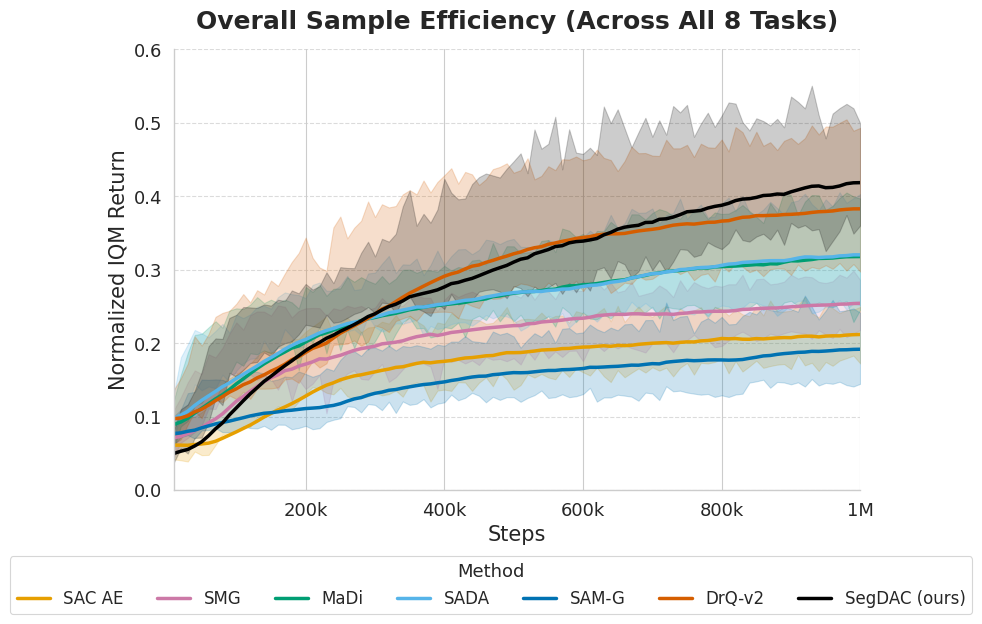

In [3]:
from scipy.stats import trim_mean
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from matplotlib.ticker import FuncFormatter

task_max_episode_lengths = {
    "PushCube-v1": 50,
    "PullCube-v1": 50,
    "PickCube-v1": 50,
    "PokeCube-v1": 50,
    "PullCubeTool-v1": 100,
    "LiftPegUpright-v1": 50,
    "UnitreeG1PlaceAppleInBowl-v1": 100,
    "UnitreeG1TransportBox-v1": 100,
}

def bootstrap_iqm_ci_1d(values, n_bootstraps=2000, ci_level=0.95):
    values = np.asarray(values, dtype=float)
    n = len(values)
    if n == 0:
        return np.nan, np.nan
    if n == 1:
        v = float(values[0])
        return v, v

    iqms = np.empty(n_bootstraps, dtype=float)
    for i in range(n_bootstraps):
        idx = np.random.randint(0, n, size=n)
        sample = values[idx]
        iqms[i] = trim_mean(sample, proportiontocut=0.25)

    lower_percentile = (1.0 - ci_level) / 2.0 * 100
    upper_percentile = (1.0 - (1.0 - ci_level) / 2.0) * 100

    lower = np.percentile(iqms, lower_percentile)
    upper = np.percentile(iqms, upper_percentile)
    return lower, upper

def smooth_curve(curve, alpha):
    if alpha == 0: return curve
    beta = alpha
    alpha = 1 - beta
    smoothed = np.zeros_like(curve)
    smoothed[0] = curve[0]
    for i in range(1, len(curve)):
        smoothed[i] = alpha * curve[i] + beta * smoothed[i - 1]
    return smoothed

agg_algo_step_values = {algo_name: {} for algo_name in algo_name_mapping.keys()}

for task_name in tasks:
    json_path = output_eval_results_folder / Path(task_name.lower() + "_eval_data.json")
    
    if not json_path.exists():
        print(f"Warning: {json_path} not found.")
        continue
        
    with open(json_path, "r") as f:
        task_data = json.load(f)

    max_episode_length = task_max_episode_lengths[task_name]

    for algo_name in algo_name_mapping.keys():
        if algo_name not in task_data:
            continue

        for seed_key, seed_info in task_data[algo_name].items():
            if seed_key == "aggregated":
                continue

            steps = np.asarray(seed_info["step"], dtype=int)
            raw_returns = np.asarray(seed_info["return"], dtype=float)
            
            norm_returns = raw_returns / max_episode_length

            for s, v in zip(steps, norm_returns):
                step_dict = agg_algo_step_values[algo_name]
                if s not in step_dict:
                    step_dict[s] = []
                step_dict[s].append(v)

fig_agg, ax_agg = plt.subplots(1, 1, figsize=(8, 6))

for algo_name, step_dict in agg_algo_step_values.items():
    if len(step_dict) == 0:
        continue

    steps = sorted(step_dict.keys())
    iqm_vals = []
    lower_vals = []
    upper_vals = []

    for s in steps:
        vals = np.asarray(step_dict[s], dtype=float)
        
        iqm_s = trim_mean(vals, proportiontocut=0.25)
        lb_s, ub_s = bootstrap_iqm_ci_1d(vals)
        
        iqm_vals.append(iqm_s)
        lower_vals.append(lb_s)
        upper_vals.append(ub_s)

    steps = np.asarray(steps, dtype=int)
    iqm_vals = np.asarray(iqm_vals)
    lower_vals = np.asarray(lower_vals)
    upper_vals = np.asarray(upper_vals)

    iqm_vals = smooth_curve(iqm_vals, SMOOTHING_ALPHA)

    color = color_map[algo_name]

    ax_agg.plot(
        steps,
        iqm_vals,
        label=algo_name_mapping[algo_name],
        color=color,
        linewidth=2.5,
    )
    ax_agg.fill_between(
        steps,
        lower_vals,
        upper_vals,
        color=color,
        alpha=0.2,
    )

ax_agg.set_title(
    f"Overall Sample Efficiency (Across All 8 Tasks)",
    fontsize=18,
    fontweight='bold',
    pad=15,
)
ax_agg.set_xlabel("Steps", fontsize=15)
ax_agg.set_ylabel("Normalized IQM Return", fontsize=15)
ax_agg.xaxis.set_major_formatter(FuncFormatter(xfmt))
ax_agg.tick_params(axis="both", labelsize=13)

all_steps_for_xlim = []
for d in agg_algo_step_values.values():
    all_steps_for_xlim.extend(list(d.keys()))
if all_steps_for_xlim:
    all_steps_for_xlim = np.asarray(all_steps_for_xlim, dtype=int)
    ax_agg.set_xlim(all_steps_for_xlim.min(), all_steps_for_xlim.max())

ax_agg.set_ylim(0, 0.6)
ax_agg.grid(True, which="major", axis="y", linestyle="--", alpha=0.7)
sns.despine(fig=fig_agg, ax=ax_agg)

handles, labels = ax_agg.get_legend_handles_labels()
fig_agg.legend(
    handles,
    labels,
    title="Method",
    fontsize=12,
    title_fontsize=13,
    loc="lower center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, -0.05),
    frameon=True,
)

fig_agg.tight_layout(rect=(0, 0.05, 1, 1))

agg_out_fname = output_plots_folder / Path(
    "aggregated_iqm_normalized_return_smoothed.pdf"
)
fig_agg.savefig(agg_out_fname, bbox_inches="tight")
plt.show()